In [ ]:
# Quiz Configuration Features


## 1. Setup and Data Loading


In [2]:
# 1. Imports, configuration, and data loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import warnings
import re
from IPython.display import display

# Configure plotting style and pandas display for consistent visuals
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Define base paths for ETL outputs
base_path = Path('../etl-output')
quizzes_path = base_path / 'quizzes' / 'quizobjects' / 'data'
orgunits_path = base_path / 'organizationalunits' / 'organizationalunits' / 'data'

# --- Load quizzes dataset (Quizzes tool extract) ---
print("Loading Quizzes dataset...")
quiz_files = sorted(glob.glob(str(quizzes_path / 'part-*.csv')))
print(f"Found {len(quiz_files)} CSV files for quizzes")

# Concatenate all quiz CSV parts into a single DataFrame
df_quizzes = pd.concat([pd.read_csv(f, low_memory=False) for f in quiz_files], ignore_index=True)
print(f"Loaded {len(df_quizzes):,} quizzes")
print(f"Columns: {df_quizzes.shape[1]}")

# --- Load organizational units dataset (for proxy "school" grouping) ---
print("\nLoading Organizational Units dataset...")
org_files = sorted(glob.glob(str(orgunits_path / 'part-*.csv')))
print(f"Found {len(org_files)} CSV files for org units")

df_orgunits = pd.concat([pd.read_csv(f, low_memory=False) for f in org_files], ignore_index=True)
print(f"Loaded {len(df_orgunits):,} organizational units")
print(f"Columns: {df_orgunits.shape[1]}")

# --- Define configuration features of interest ---
features = [
    'has_password',
    'ip_restricted',
    'time_limit_enforced',
    'prevent_moving_backwards',
    'allow_hints',
    'display_in_calendar',
    'is_retake_incorrect_only',
]

# Keep only features that actually exist in the quizzes dataset
feature_cols = [f for f in features if f in df_quizzes.columns]

# Ensure these columns are boolean with no nulls for consistent counting
for col in feature_cols:
    df_quizzes[col] = df_quizzes[col].fillna(False).astype(bool)

# This is the denominator for all percentages in this notebook
total_quizzes = len(df_quizzes)
print(f"\nTotal quiz records in df_quizzes: {total_quizzes:,}")
print("All percentages below use this as the denominator (quizzes only, no surveys/self-assessments).")


Loading Quizzes dataset...
Found 1 CSV files for quizzes
Loaded 701,708 quizzes
Columns: 37

Loading Organizational Units dataset...
Found 4 CSV files for org units
Loaded 1,146,091 organizational units
Columns: 14

Total quiz records in df_quizzes: 701,708
All percentages below use this as the denominator (quizzes only, no surveys/self-assessments).


## 2. Overall quiz configuration features (quizzes only)

This section summarizes how often selected configuration flags are enabled across
all records in the `df_quizzes` dataset.

- Percentages use **all quiz records** in `df_quizzes` as the denominator.
- `df_quizzes` is sourced from `../etl-output/quizzes/quizobjects/data`, which
  is the **Quizzes tool** extract (surveys and self-assessments live in
  separate datasets).
- So a value like `44%` for `Time Limit Enforced` should be read as:

  > "44% of quizzes in the Quizzes tool extract have a time limit enforced."


Overall configuration feature usage across all quizzes (quizzes only):


,Feature,Count,Percentage
2,Time Limit Enforced,310056,44.185901
1,Ip Restricted,107062,15.257344
5,Display In Calendar,100865,14.374213
0,Has Password,44000,6.270414
3,Prevent Moving Backwards,37116,5.289380
4,Allow Hints,20930,2.982722
6,Is Retake Incorrect Only,13009,1.853905


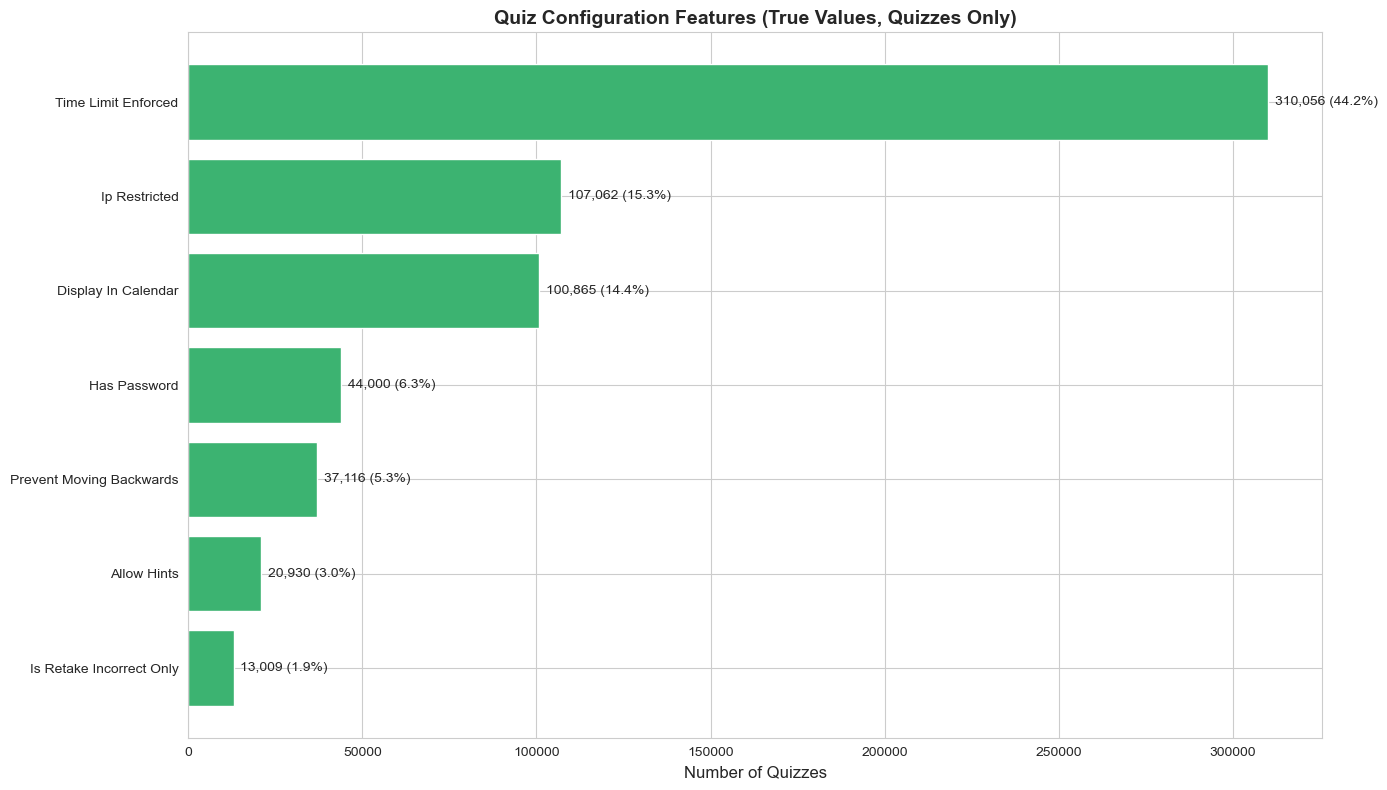

In [3]:
# 2. Overall quiz configuration feature distribution

# Compute how many quizzes have each configuration flag enabled
feature_counts = df_quizzes[feature_cols].sum()

# Build a tidy summary table with readable feature names and percentages
feature_df = (
    feature_counts
    .rename_axis('Raw_Feature')  # index name before reset
    .reset_index(name='Count')   # move index into a column
)
feature_df['Feature'] = (
    feature_df['Raw_Feature']
    .str.replace('_', ' ', regex=False)
    .str.title()
)
feature_df['Percentage'] = feature_df['Count'] / total_quizzes * 100
feature_df = feature_df.sort_values('Count', ascending=False)[['Feature', 'Count', 'Percentage']]

print("Overall configuration feature usage across all quizzes (quizzes only):")
display(feature_df)

# Visualize as a horizontal bar chart for easier comparison
fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(range(len(feature_df)), feature_df['Count'].values, color='mediumseagreen')
ax.set_yticks(range(len(feature_df)))
ax.set_yticklabels(feature_df['Feature'].values)
ax.set_xlabel('Number of Quizzes', fontsize=12)
ax.set_title('Quiz Configuration Features (True Values, Quizzes Only)', fontsize=14, fontweight='bold')
ax.invert_yaxis()  # highest values at the top

# Annotate each bar with both count and percentage
for i, (v, pct) in enumerate(zip(feature_df['Count'].values, feature_df['Percentage'].values)):
    ax.text(
        v + max(total_quizzes * 0.001, 2000),  # offset so labels do not overlap bars
        i,
        f'{v:,} ({pct:.1f}%)',
        va='center'
    )

plt.tight_layout()
plt.show()


## 3. How many configuration flags are enabled per quiz?

This section counts, for each quiz, **how many** of the selected configuration
flags are turned on, and highlights quizzes with **three or more** enabled.

This addresses the question:

> "How many quizzes have more than 3 of these configurations enabled?"


Number of selected configuration flags enabled per quiz (quizzes only):


,Num_Features_Enabled,Quiz_Count,Percentage
0,0,303279,43.220114
1,1,198079,28.228123
2,2,168947,24.076539
3,3,28712,4.091730
4,4,2526,0.359979
5,5,165,0.023514


Quizzes with ≥3 of the selected configuration flags enabled: 31,403 (4.5% of all quizzes)


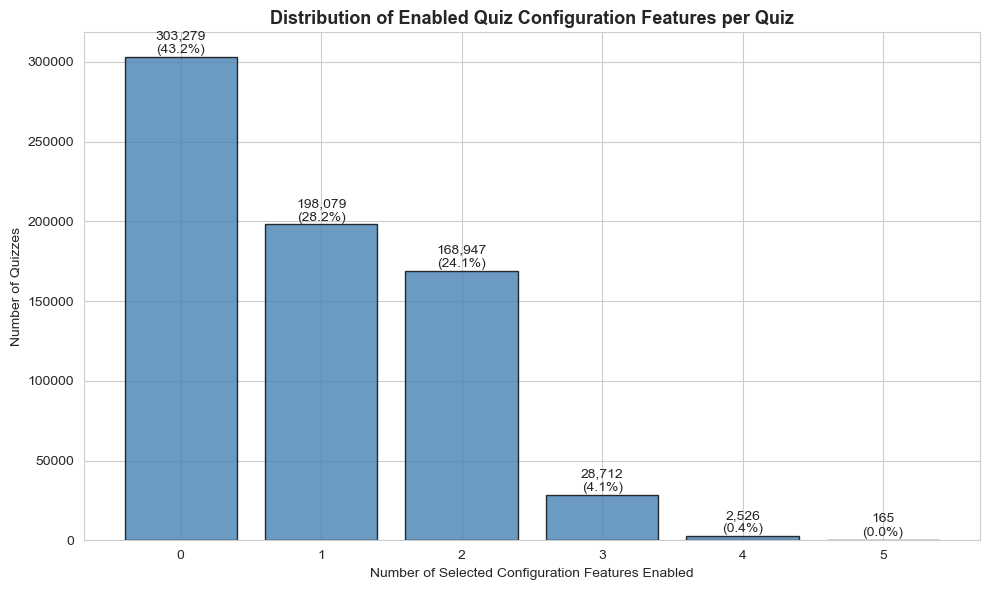

In [4]:
# 3. Distribution of number of enabled configuration features per quiz

# Count how many of the selected configuration flags are enabled for each quiz
feature_count_per_quiz = df_quizzes[feature_cols].sum(axis=1)

# Aggregate into a simple frequency table
config_count_summary = (
    feature_count_per_quiz
    .value_counts()
    .sort_index()
    .rename_axis('Num_Features_Enabled')  # 0, 1, 2, 3, ... flags enabled
    .reset_index(name='Quiz_Count')       # how many quizzes fall into each bucket
)
config_count_summary['Percentage'] = (
    config_count_summary['Quiz_Count'] / total_quizzes * 100
)

print("Number of selected configuration flags enabled per quiz (quizzes only):")
display(config_count_summary)

# Quizzes with 3 or more configuration flags turned on
quizzes_with_3_or_more = (feature_count_per_quiz >= 3).sum()
pct_with_3_or_more = (
    quizzes_with_3_or_more / total_quizzes * 100
    if total_quizzes > 0 else 0
)

print(
    f"Quizzes with \
"
    f"\u22653 of the selected configuration flags enabled: "
    f"{quizzes_with_3_or_more:,} ({pct_with_3_or_more:.1f}% of all quizzes)"
)

# Visualize the distribution of feature-counts per quiz
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    config_count_summary['Num_Features_Enabled'],
    config_count_summary['Quiz_Count'],
    color='steelblue', edgecolor='black', alpha=0.8,
)
ax.set_xlabel('Number of Selected Configuration Features Enabled')
ax.set_ylabel('Number of Quizzes')
ax.set_title(
    'Distribution of Enabled Quiz Configuration Features per Quiz',
    fontsize=13, fontweight='bold',
)

# Label each bar with count and percentage
for x, y, pct in zip(
    config_count_summary['Num_Features_Enabled'],
    config_count_summary['Quiz_Count'],
    config_count_summary['Percentage'],
):
    ax.text(
        x,
        y + max(total_quizzes * 0.0005, 500),  # small vertical offset for readability
        f'{y:,}\n({pct:.1f}%)',
        ha='center', va='bottom',
    )

plt.tight_layout()
plt.show()


## 4. Co-occurring configurations when IP restrictions are enabled

This section focuses only on quizzes where `ip_restricted == True` and asks:

> "If a quiz has IP restrictions turned on, how often does it also have a
>  password, a time limit, or other configuration flags enabled?"

We compute, for each configuration flag, the percentage of **IP-restricted
quizzes** that also have that flag enabled.

Quizzes with IP restrictions enabled: 107,062 (15.3% of all quizzes)

Among IP-restricted quizzes, share with other features enabled:


,Feature,Quizzes_with_IP_and_Feature,Percentage_of_IP_quizzes
1,Time Limit_Enforced,91621,85.577516
0,Has Password,5838,5.452915
4,Display In_Calendar,5811,5.427696
3,Allow Hints,1040,0.971400
2,Prevent Moving_Backwards,992,0.926566
5,Is Retake_Incorrect_Only,68,0.063515


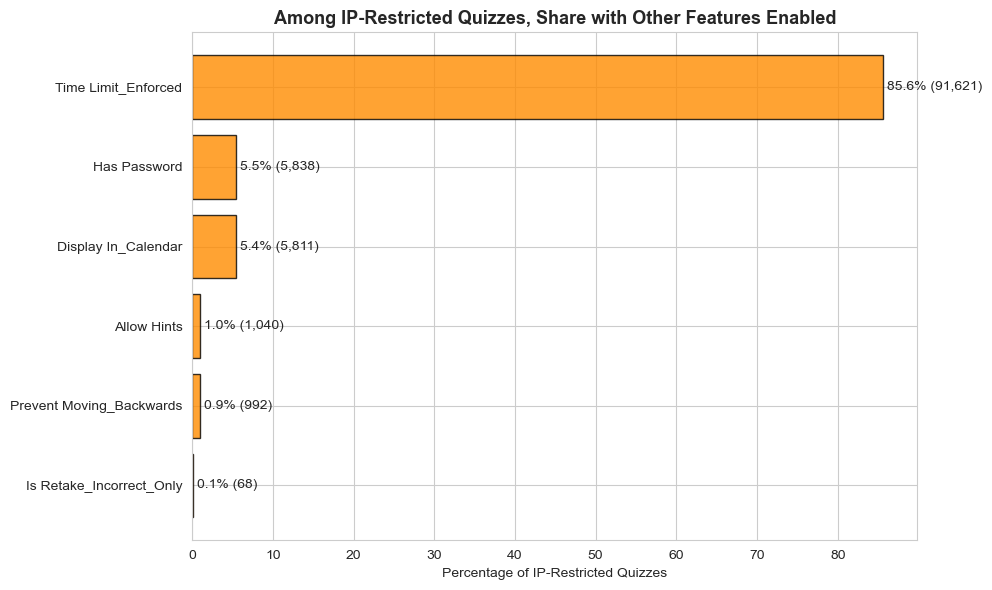

In [5]:
# 4. Co-occurrence among quizzes with IP restrictions enabled

if 'ip_restricted' in feature_cols:
    # Subset to quizzes where IP restrictions are turned on
    ip_subset = df_quizzes[df_quizzes['ip_restricted']]
    num_ip_quizzes = len(ip_subset)

    print(
        f"Quizzes with IP restrictions enabled: {num_ip_quizzes:,} "
        f"({num_ip_quizzes / total_quizzes * 100:.1f}% of all quizzes)"
    )

    coocc_rows = []

    # For each other feature, compute how often it is also enabled
    for feature in feature_cols:
        if feature == 'ip_restricted':
            # Skip the conditioning feature itself
            continue

        both_true = ip_subset[feature].sum()
        pct_of_ip = (
            both_true / num_ip_quizzes * 100
            if num_ip_quizzes > 0 else 0
        )

        coocc_rows.append({
            'Feature': feature.replace('_', ' ', 1).title(),
            'Quizzes_with_IP_and_Feature': both_true,
            'Percentage_of_IP_quizzes': pct_of_ip,
        })

    coocc_df = (
        pd.DataFrame(coocc_rows)
        .sort_values('Percentage_of_IP_quizzes', ascending=False)
    )

    print("\nAmong IP-restricted quizzes, share with other features enabled:")
    display(coocc_df)

    # Visualize co-occurrence as a horizontal bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        coocc_df['Feature'],
        coocc_df['Percentage_of_IP_quizzes'],
        color='darkorange', edgecolor='black', alpha=0.8,
    )
    ax.invert_yaxis()  # highest co-occurrence at the top
    ax.set_xlabel('Percentage of IP-Restricted Quizzes')
    ax.set_title(
        'Among IP-Restricted Quizzes, Share with Other Features Enabled',
        fontsize=13, fontweight='bold',
    )

    # Label each bar with percentage and count
    for i, (feature, pct, count) in enumerate(zip(
        coocc_df['Feature'],
        coocc_df['Percentage_of_IP_quizzes'],
        coocc_df['Quizzes_with_IP_and_Feature'],
    )):
        ax.text(
            pct + 0.5,
            i,
            f'{pct:.1f}% ({count:,})',
            va='center',
        )

    plt.tight_layout()
    plt.show()
else:
    print("Column 'ip_restricted' is not available in df_quizzes.")


## 5. Configuration patterns by school (proxy grouping)

The `organizationalunits` dataset does not contain an explicit "school" field,
so we approximate one using course codes and names (e.g., `COMP`, `NURS`).

This section addresses:

> "Do some schools rely on certain configurations more frequently?"

Interpret this as patterns by **course-code family**, not official academic
schools.


Top 15 schools (proxy) by number of quizzes:


school
COMP    30668
AVAM    22577
MKTG    19462
OPMT    17813
AMLL    15901
AELX    13209
BUSA    13151
NSCC    13089
ACAR    12538
ASTO    12488
COMM    11471
NSPN    10991
BHSC    10649
OCHS    10574
ACRP    10379
Name: quiz_id, dtype: int64


Feature usage rates (% of quizzes) by school (proxy grouping):


,quiz_count,has_password,ip_restricted,time_limit_enforced,prevent_moving_backwards,allow_hints,display_in_calendar,is_retake_incorrect_only
school,,,,,,,,
COMP,30668,26.744489,4.372636,55.412808,3.753098,0.893439,16.323203,0.332594
AVAM,22577,0.345484,52.163706,56.836604,0.004429,0.000000,3.716171,0.000000
MKTG,19462,4.372624,0.123317,55.698284,10.805673,1.284555,35.392046,0.226082
OPMT,17813,5.759838,2.947286,43.889294,12.333689,18.183349,18.424746,19.715938
AMLL,15901,2.131941,0.000000,2.264009,0.226401,0.037733,0.157223,0.333312
AELX,13209,6.995231,21.712469,57.506246,6.154894,3.164509,3.512756,0.961466
BUSA,13151,2.319215,0.243328,43.989050,18.690594,0.844042,22.614250,0.007604
NSCC,13089,4.782642,0.000000,23.103369,0.000000,0.145160,12.460845,0.000000
ACAR,12538,0.000000,37.159037,49.712873,0.000000,0.000000,2.831393,1.794545


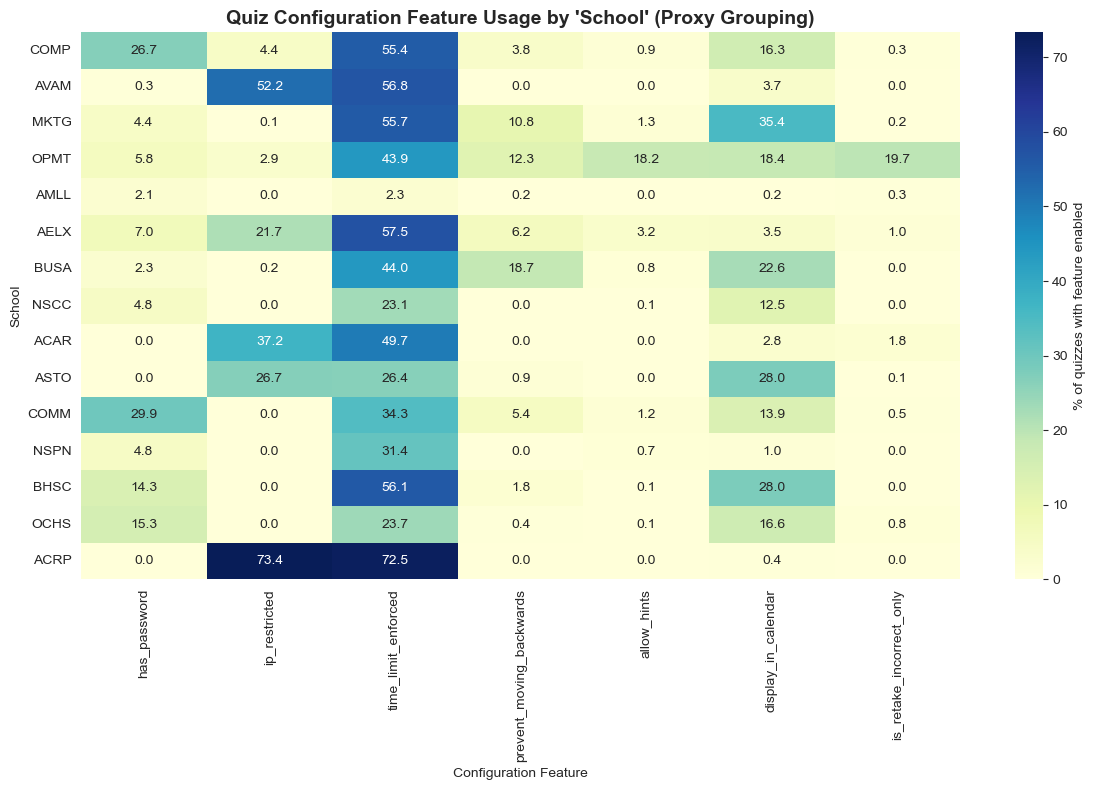

In [6]:
# 5. Configuration feature usage by proxy "school" grouping

# Start from a minimal view of the organizational units data
org = df_orgunits[['org_unit_id', 'name', 'code']].copy()
org['code'] = org['code'].fillna('').astype(str)
org['name'] = org['name'].fillna('').astype(str)

# Heuristic: extract a leading alphabetic token from code or name as a proxy
# for a "school" or department prefix (e.g., COMP, NURS, OPMT).
def derive_school_prefix(row):
    # Prefer a prefix from the course code (e.g., COMP 1113)
    m = re.match(r'([A-Za-z]{3,})', row['code'])
    if m:
        return m.group(1).upper()

    # Fallback: use a leading word from the org unit name
    m = re.match(r'([A-Za-z]{3,})', row['name'])
    if m:
        return m.group(1).upper()

    # If nothing else, mark as UNKNOWN so it does not silently disappear
    return 'UNKNOWN'

# Apply the heuristic to derive a proxy school code
org['school'] = org.apply(derive_school_prefix, axis=1)

# Join quizzes to org unit metadata to attach school information
quiz_org = df_quizzes.merge(
    org[['org_unit_id', 'school']],
    on='org_unit_id',
    how='left',
)
quiz_org['school'] = quiz_org['school'].fillna('UNKNOWN')

# Count quizzes per school to see which groupings are most common
school_quiz_counts = (
    quiz_org.groupby('school')['quiz_id']
    .nunique()
    .sort_values(ascending=False)
)

print("Top 15 schools (proxy) by number of quizzes:")
display(school_quiz_counts.head(15))

# Focus on the top N schools for clearer visualizations
top_schools = school_quiz_counts.head(15).index.tolist()

rows = []
for school in top_schools:
    subset = quiz_org[quiz_org['school'] == school]

    # For each school, compute the percentage of quizzes with each feature enabled
    row = {
        'school': school,
        'quiz_count': len(subset),
    }
    for feature in feature_cols:
        row[feature] = subset[feature].mean() * 100  # % of quizzes with feature enabled

    rows.append(row)

# Build a summary table indexed by school
school_feature_df = pd.DataFrame(rows).set_index('school')

print("\nFeature usage rates (% of quizzes) by school (proxy grouping):")
display(school_feature_df)

# Visualize configuration usage patterns across schools as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    school_feature_df[feature_cols],
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    cbar_kws={'label': '% of quizzes with feature enabled'},
)
plt.title(
    "Quiz Configuration Feature Usage by 'School' (Proxy Grouping)",
    fontsize=14, fontweight='bold',
)
plt.xlabel('Configuration Feature')
plt.ylabel('School')
plt.tight_layout()
plt.show()
